In [209]:
import geopandas
import numpy as np
from scipy.optimize import minimize, Bounds
from scipy.interpolate import splprep, splev
from shapely.geometry import LineString, Point
import matplotlib.pyplot as plt

In [210]:
treefall = geopandas.read_file("Treefall.shp")
reference_gdf = geopandas.read_file("ManualTornadoPath.shp")
reference_line = reference_gdf.geometry.unary_union
def get_tree_vector(line):
    x0, y0, *_ = line.coords[0]
    x1, y1, *_ = line.coords[-1]
    return np.arctan2(y1 - y0, x1 - x0)

coords = np.array([
    (geom.centroid.x, geom.centroid.y)
    for geom in treefall.geometry
], dtype=float)

angles_obs = np.array([
    get_tree_vector(geom)
    for geom in treefall.geometry
])
origin = coords.min(axis=0)
coords_n = coords - origin
slice_width = 50
slices = []

xmin, ymin = coords_n.min(axis=0)
xmax, ymax = coords_n.max(axis=0)

x = xmin
xs = coords_n[:, 0]

xmin, xmax = xs.min(), xs.max()
edges = np.arange(xmin, xmax + slice_width, slice_width)

slices = [
    (coords_n[:, 0] >= edges[i]) & (coords_n[:, 0] < edges[i + 1])
    for i in range(len(edges) - 1)
]

C:\Users\trith\AppData\Local\Temp\ipykernel_43132\2736171374.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  reference_line = reference_gdf.geometry.unary_union


In [211]:
def sample_thresholds(n, mu=15.0, beta=5.0, seed=None):
    rng = np.random.default_rng(seed)
    return rng.gumbel(mu, beta, n)

In [ ]:
def vortex_wind(x, y, xc, yc, Vmax, Rmax, inflow=0.3):
    dx = x - xc
    dy = y - yc
    r = np.hypot(dx, dy) + 1e-6
    er_x, er_y = dx / r, dy / r
    et_x, et_y = -dy / r, dx / r
    if r < Rmax:
        vt = Vmax * (r / Rmax)
    else:
        vt = Vmax * (Rmax / r)

    vr = -inflow * vt
    u = vt * et_x + vr * er_x
    v = vt * et_y + vr * er_y

    return u, v

In [ ]:
def build_path(params):
    return [(params[i], params[i+1]) for i in range(0, len(params), 2)]
def simulate_treefall(coords, path, tornado_params, thresholds):
    Vmax, Rmax, inflow, translation_speed = tornado_params

    n = len(coords)

    best_speed = np.full(n, -np.inf)
    fallen_dir = np.zeros(n)

    for t in range(len(path)):
        xc, yc = path[t]

        if t < len(path) - 1:
            dx = path[t+1][0] - xc
            dy = path[t+1][1] - yc
            norm = np.hypot(dx, dy) + 1e-6
            tx, ty = dx/norm, dy/norm
        else:
            tx, ty = 0.0, 0.0

        for i, (x, y) in enumerate(coords):

            u, v = vortex_wind(x, y, xc, yc, Vmax, Rmax, inflow)

            u_total = u + translation_speed * tx
            v_total = v + translation_speed * ty

            speed = np.hypot(u_total, v_total)
            if speed > best_speed[i]:
                best_speed[i] = speed
                fallen_dir[i] = np.arctan2(v_total, u_total)

    return (fallen_dir + np.pi) % (2*np.pi) - np.pi

In [214]:
def angular_error_axial(sim, obs):
    mask = ~np.isnan(sim)
    if np.sum(mask) < 3:
        return 1e6 
    sim = sim[mask]
    obs = obs[mask]
    diff1 = np.angle(np.exp(1j * (sim - obs)))
    diff2 = np.angle(np.exp(1j * (sim - obs + np.pi)))
    diff = np.minimum(diff1**2, diff2**2)
    return np.mean(diff)

In [215]:
def path_penalty(path):
    path = np.array(path)
    d = np.diff(path, axis=0)
    step = np.hypot(d[:,0], d[:,1])
    return np.sum(np.maximum(step - 300, 0)**2)

In [216]:
saved_paths = []

def local_loss(center, coords_local, obs_local):
    xc, yc = center

    sim_dirs = []
    for x, y in coords_local:
        u, v = vortex_wind(x, y, xc, yc, Vmax=70, Rmax=200, inflow=0.3)
        sim_dirs.append(np.arctan2(v, u))

    sim_dirs = np.array(sim_dirs)

    diff = np.angle(np.exp(1j * (sim_dirs - obs_local)))
    return np.mean(diff**2)

In [217]:
xmin, ymin = coords_n.min(axis=0)
xmax, ymax = coords_n.max(axis=0)
ymid = (ymin + ymax) / 2
init_params = np.array([
    xmin, ymid,
    xmin + (xmax-xmin)*0.25, ymid,
    xmin + (xmax-xmin)*0.5, ymid,
    xmin + (xmax-xmin)*0.75, ymid,
    xmax, ymid
])

tornado_params = (
    89.5,   # Vmax
    60.0,  # Rmax
    0.3,    # inflow
    16.0    # translation
)
padding = 2000
lb = []
ub = []

n_points = len(init_params) // 2

for _ in range(n_points):
    lb.extend([xmin - padding, ymin - padding])
    ub.extend([xmax + padding, ymax + padding])

bounds = Bounds(lb, ub)

In [ ]:
slice_weights = []

for mask in slices:
    obs_local = angles_obs[mask]

    if len(obs_local) < 3:
        slice_weights.append(0.0)
        continue
    complex_vec = np.exp(1j * obs_local)
    coherence = np.abs(np.mean(complex_vec))

    slice_weights.append(coherence)

slice_weights = np.array(slice_weights)
slice_weights /= (slice_weights.max() + 1e-6)

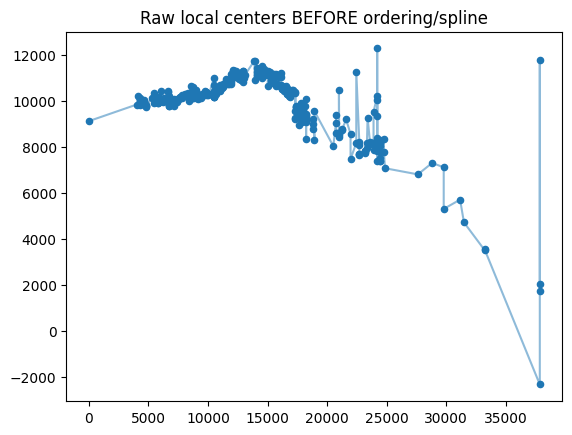

In [ ]:
local_centers = []
prev_center = None
for i, mask in enumerate(slices):
    coords_local = coords_n[mask]
    obs_local = angles_obs[mask]

    if len(coords_local) < 5:
        continue
    weight = slice_weights[i]
    x0 = np.mean(coords_local[:,0])
    y0 = np.mean(coords_local[:,1])

    scale = np.std(coords_local)

    def slice_loss(center):
        base = local_loss(center, coords_local, obs_local)

        data_anchor = np.sum((center - np.mean(coords_local, axis=0))**2) / (scale**2 + 1e-6)

        if prev_center is None:
            return weight * (base + 0.05 * data_anchor)
        direction = center - prev_center
        direction_norm = np.hypot(direction[0], direction[1]) + 1e-6
        forward_penalty = max(0.0, -(direction[0] / direction_norm))

        continuity = np.sum((center - prev_center)**2) / (scale**2 + 1e-6)

        return weight * (
            base
            + 0.05 * data_anchor
            + 0.1 * continuity
            + 2.0 * forward_penalty
        )

    result = minimize(
        slice_loss,
        x0=[x0, y0],
        method="L-BFGS-B",
        options={"maxiter": 200}
    )

    prev_center = result.x
    candidate = result.x
    if len(local_centers) > 0:
        prev = local_centers[-1]

        if candidate[0] < prev[0] - 10:
            candidate[0] = prev[0] + 1e-3

    local_centers.append(candidate)
local_centers = np.array(local_centers)
plt.figure()
plt.scatter(local_centers[:,0], local_centers[:,1], s=20)
plt.plot(local_centers[:,0], local_centers[:,1], alpha=0.5)
plt.title("Raw local centers BEFORE ordering/spline")
plt.show()
keep = np.r_[True, np.diff(local_centers[:, 0]) > -1e-6]
local_centers = local_centers[keep]
n = len(local_centers)

if n < 2:
    raise ValueError("Not enough points for any spline")

k = min(3, n - 1)

tck, _ = splprep(
    [local_centers[:,0], local_centers[:,1]],
    s = len(local_centers) * 10,
    k=k
)
u = np.linspace(0, 1, 200)
smooth_path = np.array(splev(u, tck)).T
saved_paths.append(smooth_path)
sim_dirs = simulate_treefall(coords_n, smooth_path, tornado_params,
                             sample_thresholds(len(coords_n), seed=0))
errors = np.abs(np.angle(np.exp(1j * (sim_dirs - angles_obs))))

all_lines = [
    LineString([(x + origin[0], y + origin[1]) for x, y in path])
    for path in saved_paths
]

centerline = LineString([(x + origin[0], y + origin[1]) for x, y in smooth_path])
centerlineshp = geopandas.GeoDataFrame(geometry=[centerline], crs=treefall.crs)
centerlineshp.to_file("tornado_centerline.shp")
gdf_lines = geopandas.GeoDataFrame(
    {"run_id": list(range(len(all_lines)))},
    geometry=all_lines,
    crs=treefall.crs
)

gdf_lines.to_file("tornado_centerlines_MC.shp")

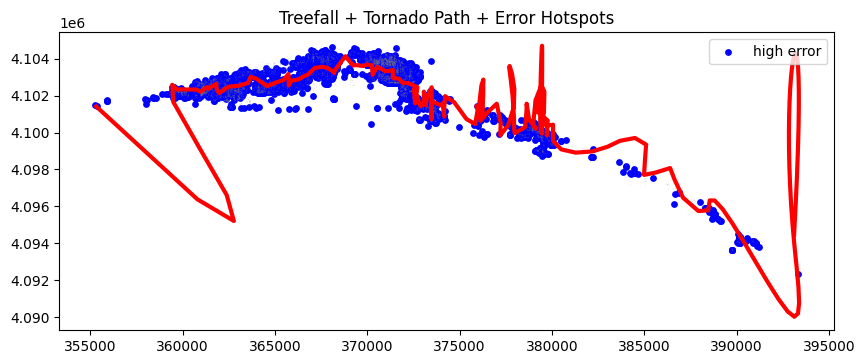

In [220]:
tree_gdf = treefall.copy()
tree_gdf["geometry"] = treefall.geometry
fig, ax = plt.subplots(figsize=(10, 10))

tree_gdf.plot(ax=ax, color="gray", linewidth=0.6, alpha=0.6)

geopandas.GeoSeries([centerline]).plot(ax=ax, color="red", linewidth=3)

if "errors" in globals():
    bad = errors > 1.0
    ax.scatter(coords[bad,0], coords[bad,1], c="blue", s=15, label="high error")

ax.legend()
ax.set_title("Treefall + Tornado Path + Error Hotspots")

plt.show()

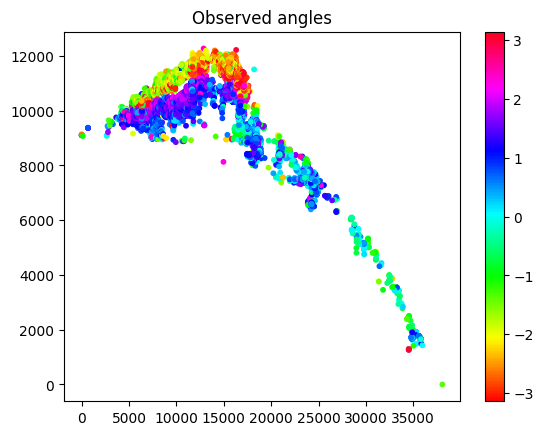

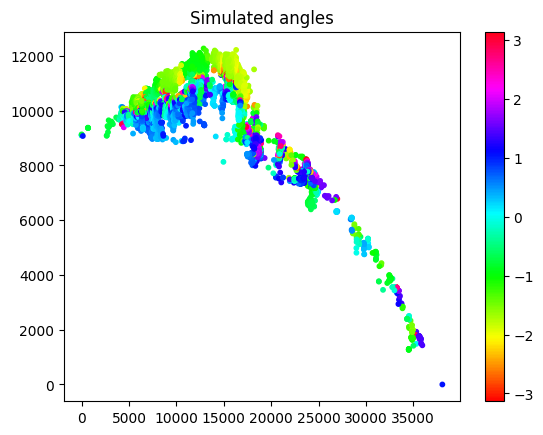

In [221]:
plt.scatter(coords_n[:,0], coords_n[:,1], c=angles_obs, cmap='hsv', s=10)
plt.title("Observed angles")
plt.colorbar()
plt.show()

plt.scatter(coords_n[:,0], coords_n[:,1], c=sim_dirs, cmap='hsv', s=10)
plt.title("Simulated angles")
plt.colorbar()
plt.show()

In [222]:
model_line = LineString(smooth_path)
ref_coords = np.array(reference_line.coords)
ref_coords = ref_coords[:, :2]
ref_coords_n = ref_coords - origin
reference_line_n = LineString(ref_coords_n)
hausdorff = model_line.hausdorff_distance(reference_line_n)
print("Hausdorff distance:", hausdorff)

Hausdorff distance: 9697.961031259112


In [223]:
num_samples = 200
model_pts = np.array([model_line.interpolate(t, normalized=True).coords[0]
                      for t in np.linspace(0, 1, num_samples)])

ref_geom = reference_line_n

distances = np.array([
    reference_line_n.distance(Point(p))
    for p in model_pts
])

mean_dist = distances.mean()
median_dist = np.median(distances)

print("Mean distance:", mean_dist)
print("Median distance:", median_dist)

Mean distance: 2039.8478209455457
Median distance: 902.4458329975093


In [224]:
np.set_printoptions(threshold=np.inf)
print(angles_obs)
print(sim_dirs)

[ 0.72606444  1.757776    0.45982826  0.84029151 -0.51914206  0.9750085
  0.9048259   1.26528698  0.33363342  0.42877583  0.45306914  0.04803535
 -0.11519078  0.01910938  0.02112749  0.29087635 -0.30970804 -0.35005101
 -0.4082739   2.27681226  2.15879893 -0.02019938  0.62192633  0.11914844
 -1.23606187 -0.52606642  0.11065326  0.90349113 -0.25168647  0.23289977
  1.57079633  0.02683882 -0.15394019 -0.59063011  0.16418702  0.68572904
  0.60308429  0.78539816  0.90976183  0.72116207  1.07938655  0.59317087
  0.49822027  0.47734307  0.66302059  1.36647495  2.07329178  1.75159141
  0.6970202   1.60701514  0.91341072  1.11897757  2.09605046  2.11244932
  1.77035972  0.4388593   1.24556698  0.41414069  2.60627923  0.42544717
  1.0851726   0.81870978  1.14417161  0.66730805  0.89605993  0.87360145
  1.0590599   0.88649872  1.23150246  1.70880209  1.78766253 -0.24998236
  1.55517144  1.71089914  1.88180477  1.85552936  1.65201054 -0.40133512
  1.51939435  1.84724425  1.51403251  0.94531266 -0.